# Video Game Sales Prediction — Gradient Boosting Model

## Step 1: Install & Import Libraries

In [ ]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb

## Step 2: Load Dataset via Kaggle API

In [ ]:
import os, json

username = ''   # Kaggle username
key    = ''   # API token

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({'username': username, 'key': key}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print('Kaggle configured!')

Kaggle configured!


In [ ]:
!kaggle datasets download -d siddharth0935/video-game-sales --unzip

df = pd.read_csv('vgchartz-2024.csv')
print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Dataset URL: https://www.kaggle.com/datasets/siddharth0935/video-game-sales
License(s): ODC Attribution License (ODC-By)
100% 1.90M/1.90M [00:00<00:00, 81.4MB/s]

Dataset loaded: 64016 rows, 14 columns


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


## Step 3: Clean Data & Extract Year

In [ ]:
# Normalize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print('Columns after normalizing names:')
print(df.columns.tolist())


# Drop columns we don't need
cols_to_drop = ['img', 'title', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'last_update']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Drop rows missing critical columns
df = df.dropna(subset=['total_sales', 'critic_score', 'developer'])

# Extract year from release_date then drop the original column
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
df = df.drop(columns=['release_date']).dropna(subset=['year'])

print(f'Rows after cleaning: {len(df)}')
df.info()
print(df.columns.tolist())

Columns after normalizing names:
['img', 'title', 'console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'release_date', 'last_update']
Rows after cleaning: 4123
<class 'pandas.core.frame.DataFrame'>
Index: 4123 entries, 0 to 18919
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   console       4123 non-null   object 
 1   genre         4123 non-null   object 
 2   publisher     4123 non-null   object 
 3   developer     4123 non-null   object 
 4   critic_score  4123 non-null   float64
 5   total_sales   4123 non-null   float64
 6   year          4123 non-null   float64
dtypes: float64(3), object(4)
memory usage: 257.7+ KB
['console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales', 'year']


## Step 4: Remove Outliers

In [ ]:
# Remove top 1% outliers in total_sales
sales_99th = df['total_sales'].quantile(0.99)
df = df[df['total_sales'] <= sales_99th].copy()

print(f'Rows after outlier removal: {len(df)}')
df.describe()

Rows after outlier removal: 4123


,publisher,developer,critic_score,total_sales,year
count,4123.000000,4123.000000,4123.000000,4123.000000,4123.000000
mean,0.737747,0.737747,7.101819,0.737747,2007.304390
std,0.537622,0.888656,1.439631,1.408878,4.759347
min,0.000000,0.000000,1.000000,0.000000,1989.000000
25%,0.409483,0.240000,6.300000,0.110000,2004.000000
50%,0.559697,0.511389,7.300000,0.300000,2008.000000
75%,1.130799,0.975000,8.100000,0.750000,2010.000000
max,4.170000,13.940000,10.000000,20.320000,2020.000000


## Step 5: Encode & Split

In [ ]:
# Target encode publisher and developer (replace with mean total_sales)
for col in ['publisher', 'developer']:
    means = df.groupby(col)['total_sales'].transform('mean')
    df[col] = means

# One-hot encode console and genre only
X = df.drop(columns=['total_sales'])
y = df['total_sales']

X_encoded = pd.get_dummies(X, columns=['console', 'genre'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)


print(f'Training samples: {len(X_train)}')
print(f'Test samples:     {len(X_test)}')
print(f'Feature count:    {X_train.shape[1]}')

Training samples: 3264
Test samples:     817
Feature count:    50


## Step 6: Scale Numeric Features

In [ ]:
scaler = StandardScaler()
num_cols = ['year', 'critic_score', 'publisher', 'developer']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print('Scaling complete.')

Scaling complete.


## Step 7: Train Gradient Boosting Model (XGBoost) with Hyperparameter Tuning


In [ ]:
param_grid = {
    'n_estimators':     [200, 400, 600],
    'learning_rate':    [0.01, 0.05, 0.1],
    'max_depth':        [4, 6, 8],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
}

search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_grid,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

print('Training Gradient Boosting model with hyperparameter tuning...')
search.fit(X_train, y_train)

best_model = search.best_estimator_
print('\nBest parameters:', search.best_params_)
print('Best CV R²:',      search.best_score_)

Training Gradient Boosting model with hyperparameter tuning...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters: {'subsample': 0.7, 'n_estimators': 600, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best CV R²: 0.5189020281344863


## Step 8: Evaluate Gradient Boosting on Test Set

In [ ]:
y_pred = best_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('=' * 45)
print('    GRADIENT BOOSTING — TEST SET RESULTS')
print('=' * 45)
print(f'  MAE  (Mean Absolute Error):   {mae:.4f}')
print(f'  MSE  (Mean Squared Error):   {mse:.4f}')
print(f'  RMSE (Root Mean Sq. Error):  {rmse:.4f}')
print(f'  R²   (R-squared Score):      {r2:.4f}')
print('=' * 45)

    GRADIENT BOOSTING — TEST SET RESULTS
  MAE  (Mean Absolute Error):   0.3755
  MSE  (Mean Squared Error):   0.4683
  RMSE (Root Mean Sq. Error):  0.6843
  R²   (R-squared Score):      0.5685


Plotting

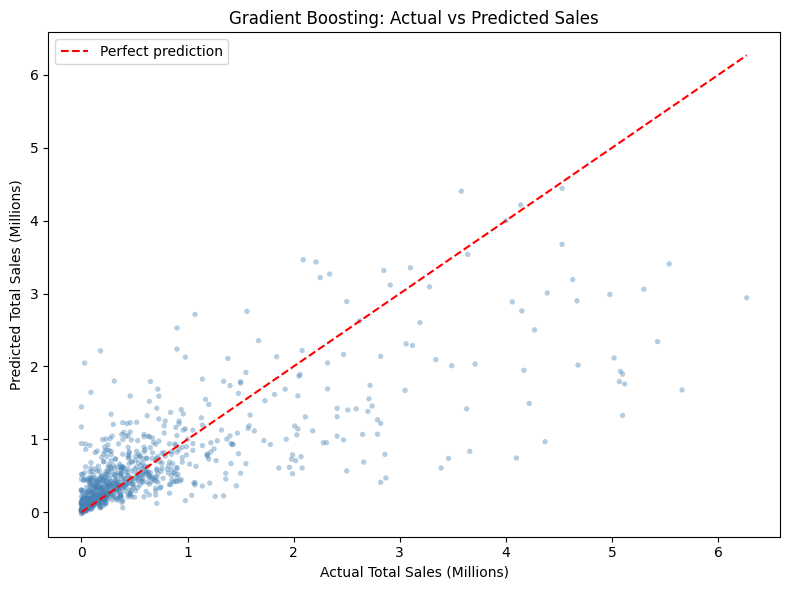

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=15, edgecolors='none')
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Total Sales (Millions)')
plt.ylabel('Predicted Total Sales (Millions)')
plt.title('Gradient Boosting: Actual vs Predicted Sales')
plt.legend()
plt.tight_layout()
plt.savefig('gb_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()